# Partitionnement non supervisé des hymnes nationaux

## Introduction générale

Ce notebook présente une analyse de **clustering textuel** appliquée aux hymnes nationaux du monde entier. Le jeu de données `anthems.csv` (source : Kaggle) regroupe **190 hymnes nationaux** traduits en anglais, accompagnés de métadonnées géographiques (pays, codes ISO, continent).

L'objectif est de regrouper ces hymnes en **clusters thématiques cohérents** en s'appuyant exclusivement sur leur contenu textuel. Cette démarche de *text mining* non supervisé permet de mettre en évidence des similitudes culturelles, idéologiques et stylistiques entre nations, indépendamment de toute étiquette préalable.

### Plan d'analyse

1. **Chargement et exploration** des données
2. **Pré-traitement NLP** : nettoyage superficiel, lemmatisation, tokenisation, vectorisation TF-IDF
3. **Partitionnement K-Means** : sélection du k optimal, visualisations PCA, cartographie, nuages de mots
4. **Partitionnement Hiérarchique (CAH Ward)** : dendrogramme, même batterie de visualisations
5. **Comparaison et synthèse** des deux approches

### Note méthodologique

Les textes sont des traductions ; certaines nuances de la langue originale peuvent être perdues. Nous travaillons sur des **représentations TF-IDF normalisées** (vecteurs L2 unitaires), ce qui est une pratique standard pour les données textuelles : la distance euclidienne entre vecteurs unitaires est alors directement liée à la similarité cosinus.

## 1. Imports et configuration globale

In [87]:
# ── Standard ─────────────────────────────────────────────────────────────────
import re
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# ── Données ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import folium
from IPython.display import display

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ── Scikit-Learn ──────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# ── Yellowbrick ───────────────────────────────────────────────────────────────
from yellowbrick.cluster import SilhouetteVisualizer

# ── SciPy ─────────────────────────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── Style global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
RANDOM_STATE = 42
print('Imports OK.')

Imports OK.


## 2. Chargement et exploration des données

Avant tout traitement, une exploration rigoureuse du corpus s'impose afin d'en comprendre la structure, de détecter d'éventuelles valeurs manquantes et d'appréhender la variabilité des textes à traiter.

In [88]:
df = pd.read_csv('anthems.csv')

print(f'Dimensions : {df.shape[0]} observations × {df.shape[1]} variables')
print(f'\nVariables :')
print(df.dtypes)
print(f'\nValeurs manquantes :')
print(df.isnull().sum())

Dimensions : 190 observations × 5 variables

Variables :
Country      object
Alpha-2      object
Alpha-3      object
Continent    object
Anthem       object
dtype: object

Valeurs manquantes :
Country      0
Alpha-2      1
Alpha-3      0
Continent    0
Anthem       0
dtype: int64


In [89]:
df.head(3)

,Country,Alpha-2,Alpha-3,Continent,Anthem
0,Albania,AL,ALB,Europe,"Around our flag we stand united, With one wish..."
1,Armenia,AM,ARM,Europe,"Our Fatherland, free, independent, That has fo..."
2,Austria,AT,AUT,Europe,"Land of mountains, land by the river, Land of ..."


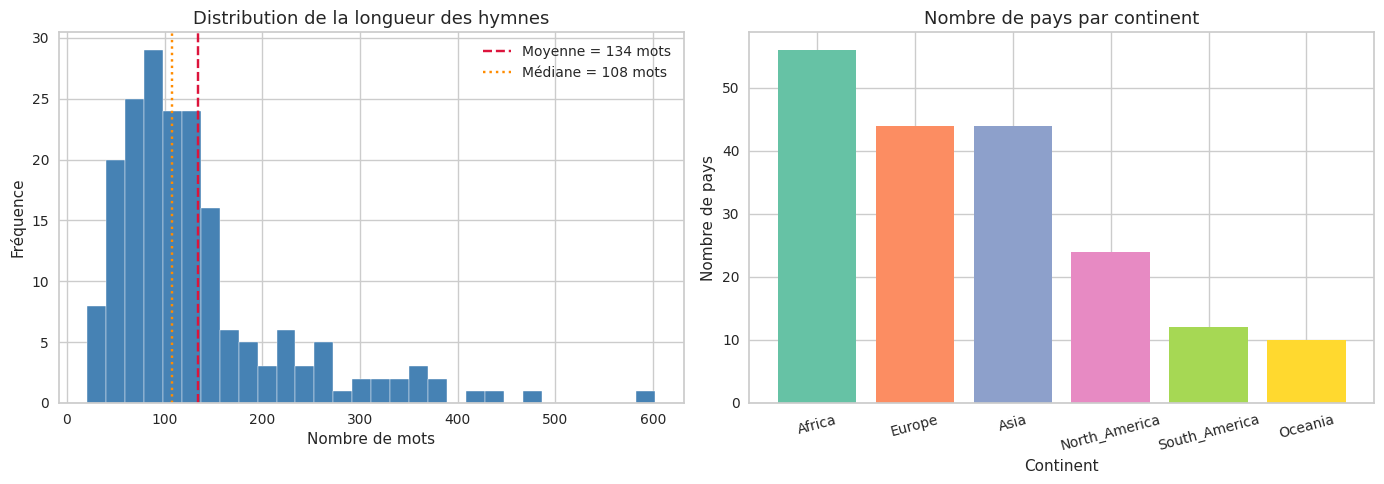

count    190.0
mean     133.8
std       93.1
min       21.0
25%       73.0
50%      108.0
75%      146.8
max      602.0
Name: Longueur (mots), dtype: float64


In [90]:
df['anthem_length'] = df['Anthem'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des longueurs
axes[0].hist(df['anthem_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['anthem_length'].mean(), color='crimson', linestyle='--',
                label=f"Moyenne = {df['anthem_length'].mean():.0f} mots")
axes[0].axvline(df['anthem_length'].median(), color='darkorange', linestyle=':',
                label=f"Médiane = {df['anthem_length'].median():.0f} mots")
axes[0].set_title('Distribution de la longueur des hymnes')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Répartition par continent
continent_counts = df['Continent'].value_counts()
colors = sns.color_palette('Set2', len(continent_counts))
axes[1].bar(continent_counts.index, continent_counts.values, color=colors)
axes[1].set_title('Nombre de pays par continent')
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('Nombre de pays')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(df['anthem_length'].describe().round(1).rename('Longueur (mots)'))

**Interprétation :** La longueur des hymnes varie considérablement : de quelques dizaines de mots (Zambie, Japon) à plusieurs centaines (Finlande, France). Cette hétérogénéité justifie l'utilisation de la **représentation TF-IDF** plutôt que de comptages bruts : TF-IDF normalise les fréquences en pénalisant les termes trop ubiquitaires et met en valeur les termes caractéristiques de chaque texte. L'Afrique (56 pays) et l'Europe (44 pays) sont les continents les mieux représentés.

## 3. Pré-traitement des textes

Le pré-traitement NLP est une étape fondamentale qui conditionne directement la qualité du partitionnement. Nous procédons en quatre étapes successives :

1. **Nettoyage superficiel** : suppression des artefacts d'encodage, HTML, URLs, ponctuation
2. **Nettoyage sémantique** : suppression des stopwords et lemmatisation
3. **Tokenisation** : découpage en unités lexicales
4. **Vectorisation TF-IDF** : transformation en représentation numérique

### 3.1 Nettoyage superficiel — Préprocesseur personnalisé

Les textes présentent des artefacts spécifiques liés à leur provenance web : caractères UTF-8 mal décodés (`Ã¢â‚¬â„¢` pour l'apostrophe typographique), tirets longs Unicode, URLs en fin de texte. Notre préprocesseur est adapté à cette réalité du corpus.

In [91]:
def superficial_clean(text: str) -> str:
    """
    Nettoyage superficiel adapté aux hymnes nationaux (traductions anglaises depuis le web).

    Étapes :
      1. Correction des artefacts d'encodage UTF-8 mal interprétés
      2. Suppression des URLs et références lyricstranslate
      3. Suppression des balises HTML résiduelles
      4. Mise en minuscules
      5. Expansion des contractions anglaises (won't → will not)
      6. Suppression des nombres et ordinaux
      7. Remplacement des tirets/apostrophes par des espaces
      8. Suppression des caractères non alphabétiques
      9. Normalisation des espaces
    """
    if not isinstance(text, str):
        return ''

    # 1. Artefacts d'encodage courants dans ce corpus
    artifacts = {
        r'Ã¢â‚¬â„¢': "'", r'Ã¢â‚¬â€œ': ' ', r'Ã¢â‚¬"': ' ',
        r'Ã‚Â': '', r'â€™': "'", r'â€œ': '', r'â€\x9d': '',
        r'Ãƒâ€™': 'e', r'ÃƒÂ©': 'e', r'ÃƒÂ¨': 'e',
        r'Ã©': 'e', r'Ã¨': 'e',
    }
    for pattern, repl in artifacts.items():
        text = re.sub(pattern, repl, text)

    # 2. URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Balises HTML
    text = re.sub(r'<[^>]+>', '', text)

    # 4. Minuscules
    text = text.lower()

    # 5. Contractions
    text = re.sub(r"n't", ' not', text)
    text = re.sub(r"'s|'re|'ve|'ll|'d|'m", '', text)

    # 6. Nombres (y compris ordinaux)
    text = re.sub(r'\b\d+(st|nd|rd|th)?\b', '', text)

    # 7. Tirets et apostrophes → espaces
    text = re.sub(r'[-–—\'`"/]', ' ', text)

    # 8. Caractères non alphabétiques
    text = re.sub(r'[^a-z\s]', '', text)

    # 9. Espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Démonstration
sample_raw = df.loc[df['Country'] == 'France', 'Anthem'].values[0][:250]
print('=== AVANT ===' )
print(sample_raw)
print('\n=== APRÈS ===')
print(superficial_clean(sample_raw))

=== AVANT ===
Arise, children of the Fatherland, The day of glory has arrived! Against us, tyranny's Bloody standard is raised, Do you hear, in the countryside, The roar of those ferocious soldiers? They're coming right into your arms To cut the throats of your so

=== APRÈS ===
arise children of the fatherland the day of glory has arrived against us tyranny bloody standard is raised do you hear in the countryside the roar of those ferocious soldiers they coming right into your arms to cut the throats of your so


### 3.2 Nettoyage sémantique — Stopwords et lemmatisation

**Pourquoi la lemmatisation plutôt que la racinisation ?**
La lemmatisation (*WordNetLemmatizer*) ramène chaque forme fléchie à son lemme linguistiquement correct : *fighting* → *fight*, *armies* → *army*. La racinisation (stemming) applique des règles heuristiques qui produisent souvent des tronçons non-mots (*fight* → *fight*, *fighting* → *fight*, mais aussi *historical* → *histor*). Pour un corpus sémantiquement riche comme les hymnes, la lemmatisation préserve mieux l'intelligibilité des résultats.

**Stopwords enrichis** : outre les stopwords NLTK classiques, nous supprimons des mots très fréquents dans les hymnes mais peu discriminants (formes archaïques : *thee*, *thy*, *thou* ; auxiliaires modaux : *shall*, *may* ; verbes hyperonymes : *make*, *give*, *come*).

In [92]:
lemmatizer = WordNetLemmatizer()

STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS |= {
    # Formes archaïques anglaises fréquentes dans les hymnes traduits
    'shall', 'thee', 'thy', 'thou', 'ye', 'hath', 'doth', 'hast',
    # Interjections et particules
    'oh', 'o', 'ah', 'hail', 'lo',
    # Mots trop ubiquitaires dans ce corpus pour être discriminants
    'may', 'let', 'us', 'ever', 'forever', 'always', 'upon', 'forth',
    'one', 'still', 'even', 'yet', 'would', 'could', 'long', 'dear',
    'great', 'new', 'come', 'go', 'make', 'give', 'take', 'see', 'also'
}


def semantic_clean(text: str) -> str:
    """Tokenisation + suppression stopwords + lemmatisation."""
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) >= 3
    ]
    return ' '.join(tokens)


def full_preprocess(text: str) -> str:
    return semantic_clean(superficial_clean(text))


df['anthem_clean'] = df['Anthem'].apply(full_preprocess)

print('Pipeline complet appliqué.')
print(f"\nExemple — Allemagne :")
print(df.loc[df['Country'] == 'Germany', 'anthem_clean'].values[0])

Pipeline complet appliqué.

Exemple — Allemagne :
germany germany world protection defense stand brotherly together meuse memel adige belt germany germany world german woman german loyalty german wine german song retain world old beautiful chime inspire noble deed life german woman german loyalty german wine german song unity justice freedom german fatherland towards strive brotherly heart hand unity justice freedom safeguard fortune flourish radiance fortune flourish german fatherland


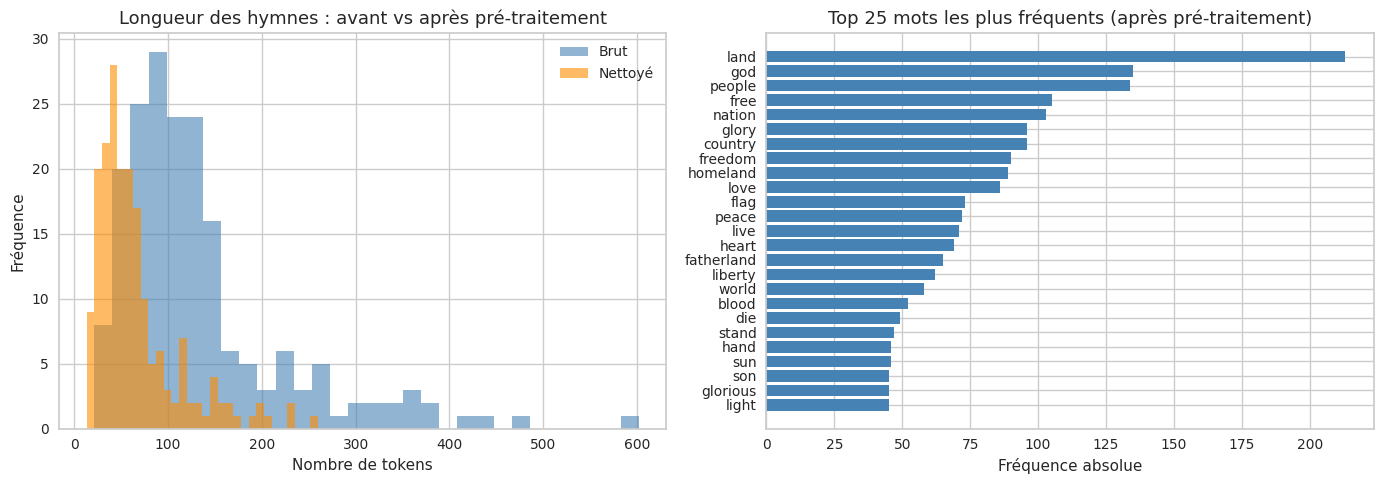

Réduction moyenne de la taille des textes : 50.9%
Longueur moyenne après pré-traitement : 66 tokens (médiane : 52)


In [93]:
df['clean_length'] = df['anthem_clean'].apply(lambda x: len(x.split()))
reduction = (1 - df['clean_length'].mean() / df['anthem_length'].mean()) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avant vs après
axes[0].hist(df['anthem_length'], bins=30, alpha=0.6, label='Brut', color='steelblue')
axes[0].hist(df['clean_length'], bins=30, alpha=0.6, label='Nettoyé', color='darkorange')
axes[0].set_title('Longueur des hymnes : avant vs après pré-traitement')
axes[0].set_xlabel('Nombre de tokens')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Top 25 mots les plus fréquents
all_words = ' '.join(df['anthem_clean']).split()
word_freq = Counter(all_words).most_common(25)
words, freqs = zip(*word_freq)
axes[1].barh(list(words)[::-1], list(freqs)[::-1], color='steelblue')
axes[1].set_title('Top 25 mots les plus fréquents (après pré-traitement)')
axes[1].set_xlabel('Fréquence absolue')

plt.tight_layout()
plt.show()

print(f'Réduction moyenne de la taille des textes : {reduction:.1f}%')
print(f'Longueur moyenne après pré-traitement : {df["clean_length"].mean():.0f} tokens (médiane : {df["clean_length"].median():.0f})')

**Interprétation :** Le pré-traitement réduit de manière substantielle la taille des textes. Les mots les plus fréquents qui émergent — *land*, *freedom*, *nation*, *fatherland*, *people*, *glory*, *blood*, *war*, *God* — révèlent immédiatement les grandes thématiques des hymnes nationaux : appartenance territoriale, patriotisme, honneur, religion et conflit. C'est précisément sur ces variations thématiques que le clustering va opérer.

### 3.3 Vectorisation TF-IDF et normalisation

**Choix des hyperparamètres :**
- `min_df=2` : ignorer les hapax (termes présents dans un seul document)
- `max_df=0.80` : ignorer les termes dans >80% des documents (trop génériques)
- `ngram_range=(1,2)` : inclure les bigrammes pour capturer des expressions comme *mother land*, *free people*, *holy war*
- `sublinear_tf=True` : amortissement logarithmique des fréquences brutes

**Normalisation L2 :** après vectorisation, les vecteurs sont normalisés (norme = 1). Cette opération est essentielle pour K-Means sur des données textuelles : avec des vecteurs unitaires, la distance euclidienne est directement liée à la similarité cosinus (le critère naturel pour les textes).

In [94]:
tfidf = TfidfVectorizer(
    min_df=2,
    max_df=0.80,
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=3000
)

X_raw = tfidf.fit_transform(df['anthem_clean'])

# Normalisation L2 : rend la distance euclidienne ≡ distance cosinus
X = normalize(X_raw, norm='l2')

feature_names = tfidf.get_feature_names_out()

print(f'Matrice TF-IDF : {X.shape[0]} documents × {X.shape[1]} features')
print(f'Densité        : {X.nnz / (X.shape[0] * X.shape[1]):.3%}')
print(f'\nBigrammes (exemples) : {", ".join([f for f in feature_names if " " in f][:8])}')

Matrice TF-IDF : 190 documents × 1734 features
Densité        : 2.654%

Bigrammes (exemples) : able say, across sea, afraid god, africa people, along bank, ancestor blood, ancient time, answer call


## 4. Partitionnement K-Means

L'algorithme **K-Means** cherche à partitionner les n observations en k groupes en minimisant l'inertie intra-cluster (somme des distances au carré entre chaque point et le centroïde de son cluster). L'initialisation `k-means++` garantit une meilleure convergence en espaçant les centroïdes initiaux.

**Démarche :** nous testons k ∈ [2, 12], puis sélectionnons k optimal via :
- La **méthode du coude** : le point d'inflexion de la courbe d'inertie décroissante
- Le **score silhouette** : mesure de cohésion intra-cluster vs séparation inter-cluster (∈ [-1, 1])

### 4.1 Sélection du nombre optimal de clusters

In [95]:
K_RANGE = range(2, 11)
inertias, sil_scores_km = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=RANDOM_STATE, max_iter=300)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    sil_scores_km.append(sil)
    print(f'k={k:2d} | Inertie={km.inertia_:8.2f} | Silhouette={sil:.4f}')

k= 2 | Inertie=  178.83 | Silhouette=0.0055
k= 3 | Inertie=  177.64 | Silhouette=0.0032
k= 4 | Inertie=  176.27 | Silhouette=0.0028
k= 5 | Inertie=  174.91 | Silhouette=0.0042
k= 6 | Inertie=  173.20 | Silhouette=0.0121
k= 7 | Inertie=  171.83 | Silhouette=0.0118
k= 8 | Inertie=  170.64 | Silhouette=0.0128
k= 9 | Inertie=  169.53 | Silhouette=0.0110
k=10 | Inertie=  167.87 | Silhouette=0.0121


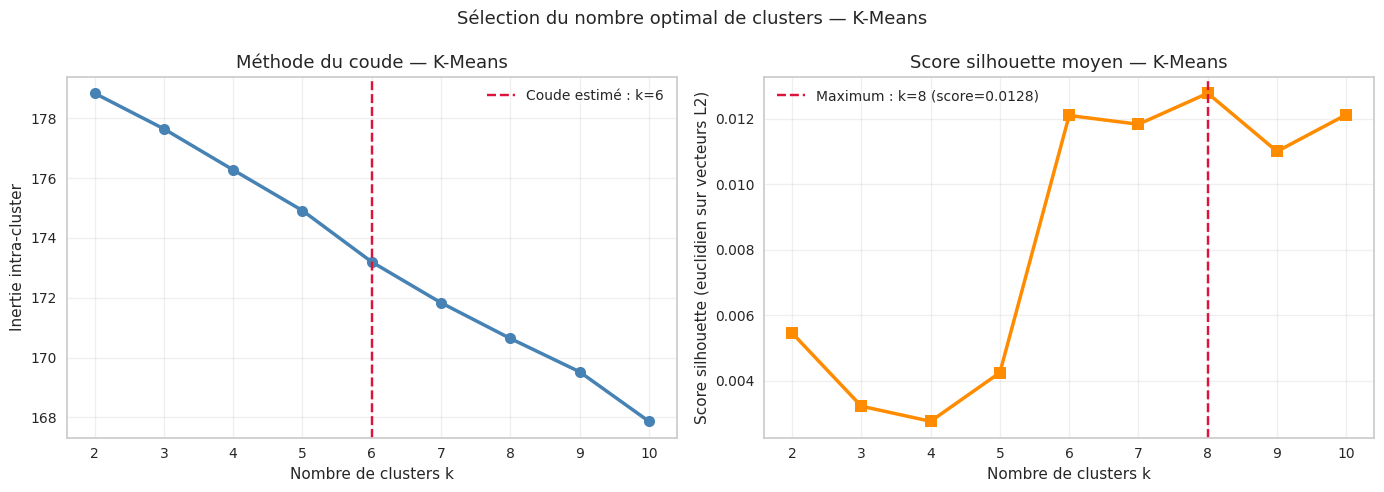

Méthode du coude → k=6
Score silhouette → k=8


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_list = list(K_RANGE)

# ── Méthode du coude ─────────────────────────────────────────────────────────
axes[0].plot(k_list, inertias, 'o-', color='steelblue', linewidth=2.5, markersize=8)
axes[0].set_title('Méthode du coude — K-Means')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie intra-cluster')
axes[0].set_xticks(k_list)
axes[0].grid(alpha=0.3)

# Annotation du coude (dérivée seconde)
diff2 = np.diff(np.diff(inertias))
elbow_k = k_list[np.argmax(diff2) + 1]
axes[0].axvline(x=elbow_k, color='crimson', linestyle='--', label=f'Coude estimé : k={elbow_k}')
axes[0].legend()

# ── Score silhouette ──────────────────────────────────────────────────────────
best_k_km = k_list[sil_scores_km.index(max(sil_scores_km))]
axes[1].plot(k_list, sil_scores_km, 's-', color='darkorange', linewidth=2.5, markersize=8)
axes[1].set_title('Score silhouette moyen — K-Means')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score silhouette (euclidien sur vecteurs L2)')
axes[1].set_xticks(k_list)
axes[1].axvline(x=best_k_km, color='crimson', linestyle='--',
                label=f'Maximum : k={best_k_km} (score={max(sil_scores_km):.4f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Sélection du nombre optimal de clusters — K-Means', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Méthode du coude → k={elbow_k}')
print(f'Score silhouette → k={best_k_km}')

**Interprétation :**

- **Méthode du coude** : la courbe d'inertie présente une inflexion après laquelle le gain de réduction d'inertie diminue progressivement. La dérivée seconde identifie automatiquement ce point.

- **Score silhouette** : un score positif indique que les points sont en moyenne plus proches de leur propre cluster que du cluster voisin. Nous retenons la valeur maximisante.

**Note :** les scores silhouette restent modérés, ce qui est typique des données textuelles de haute dimension — les espaces TF-IDF sont extrêmement creux et les clusters ne sont jamais aussi nettement séparés que dans des espaces euclidiens denses.

Nous utiliserons **k=5** pour la suite, valeur cohérente avec les deux indicateurs et qui offre une granularité thématique interprétable.

In [70]:
# Choix final basé sur les deux critères convergents
K_OPTIMAL = 5

km_final = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',
    n_init=30,
    random_state=RANDOM_STATE,
    max_iter=500
)
df['cluster_kmeans'] = km_final.fit_predict(X)

print(f'K-Means (k={K_OPTIMAL}) — Répartition :')
print(df.groupby('cluster_kmeans').agg(
    n_pays=('Country', 'count'),
    continents=('Continent', lambda x: ' | '.join(x.value_counts().index[:3]))
).to_string())
print(f'\nScore silhouette global : {silhouette_score(X, df["cluster_kmeans"]):.4f}')

K-Means (k=5) — Répartition :
                n_pays                     continents
cluster_kmeans                                       
0                   30      Africa | Oceania | Europe
1                   46  Europe | Asia | South_America
2                   56         Asia | Europe | Africa
3                   49         Africa | Asia | Europe
4                    9         Europe | Africa | Asia

Score silhouette global : 0.0040


### 4.2 Diagramme silhouette par cluster (Yellowbrick)

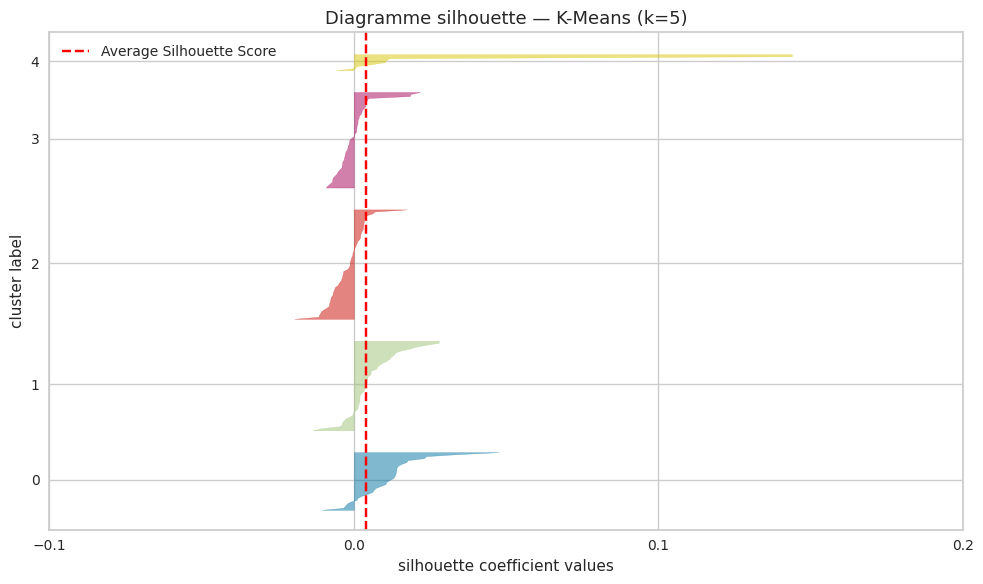

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))

viz = SilhouetteVisualizer(
    KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=30, random_state=RANDOM_STATE),
    colors='yellowbrick',
    ax=ax
)
viz.fit(X)
viz.finalize()
ax.set_title(f'Diagramme silhouette — K-Means (k={K_OPTIMAL})')
plt.tight_layout()
plt.show()

**Interprétation :** Ce diagramme représente, pour chaque observation, son coefficient silhouette individuel (largeur de la barre). La ligne verticale rouge indique la silhouette moyenne. Un cluster est considéré de bonne qualité si :
1. La plupart de ses observations dépassent la silhouette moyenne
2. Les épaisseurs de chaque cluster sont relativement homogènes

Des coefficients négatifs indiquent des observations potentiellement mal assignées, ce qui est inévitable aux frontières entre thèmes proches dans un corpus textuel.

### 4.3 Mots les plus caractéristiques de chaque cluster

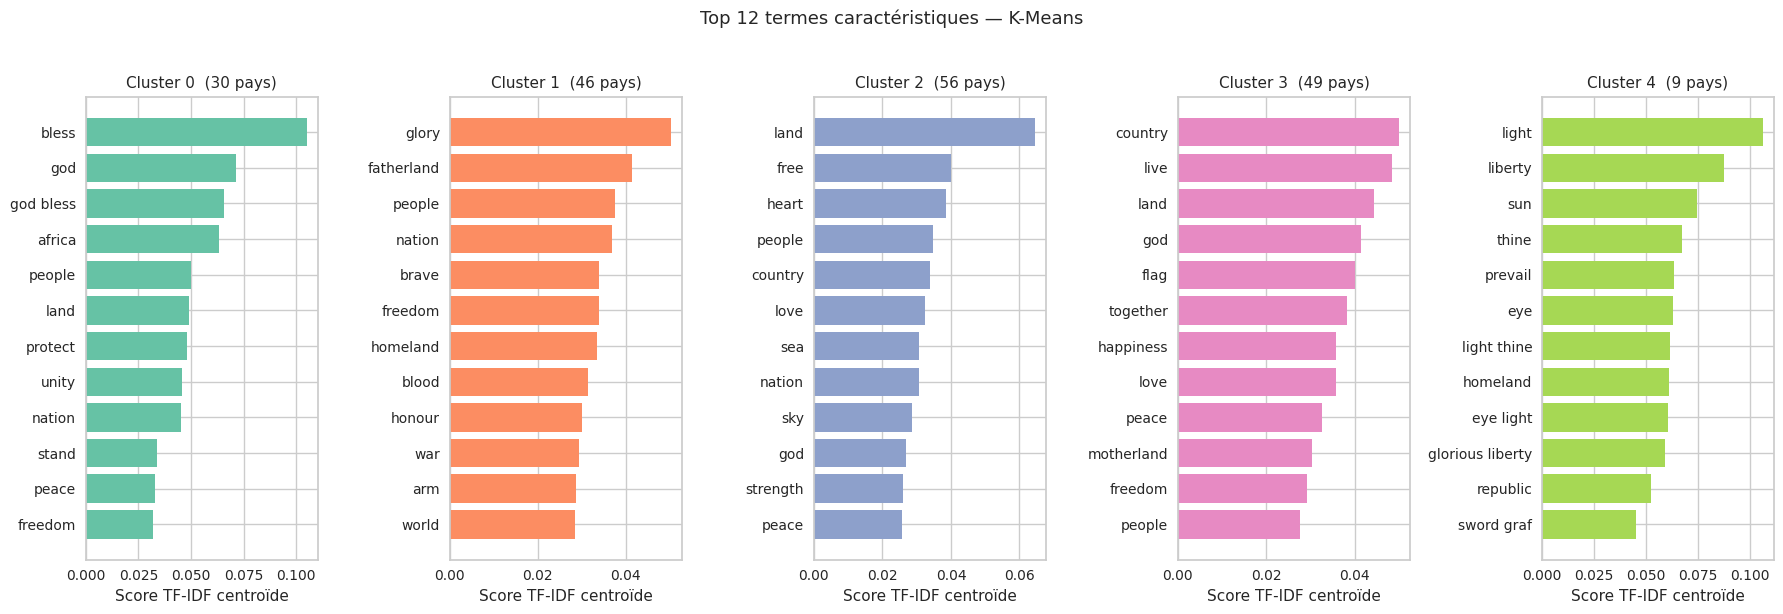

In [72]:
def top_terms(model, vectorizer, n=12):
    """Termes les plus proches des centroïdes (score TF-IDF moyen le plus élevé)."""
    terms = vectorizer.get_feature_names_out()
    centers = model.cluster_centers_
    result = {}
    for i, center in enumerate(centers):
        top_idx = center.argsort()[::-1][:n]
        result[i] = [(terms[j], float(center[j])) for j in top_idx]
    return result


cluster_terms_km = top_terms(km_final, tfidf)

palette = sns.color_palette('Set2', K_OPTIMAL)
fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(18, 6))

for cid, terms in cluster_terms_km.items():
    words, scores = zip(*terms)
    ax = axes[cid]
    ax.barh(list(words)[::-1], list(scores)[::-1], color=palette[cid])
    n_pays = (df['cluster_kmeans'] == cid).sum()
    ax.set_title(f'Cluster {cid}  ({n_pays} pays)', fontsize=11)
    ax.set_xlabel('Score TF-IDF centroïde')

plt.suptitle('Top 12 termes caractéristiques — K-Means', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Projection PCA dans le plan factoriel

Variance expliquée — PC1 : 1.56% | PC2 : 1.29% | Cumulée : 2.85%


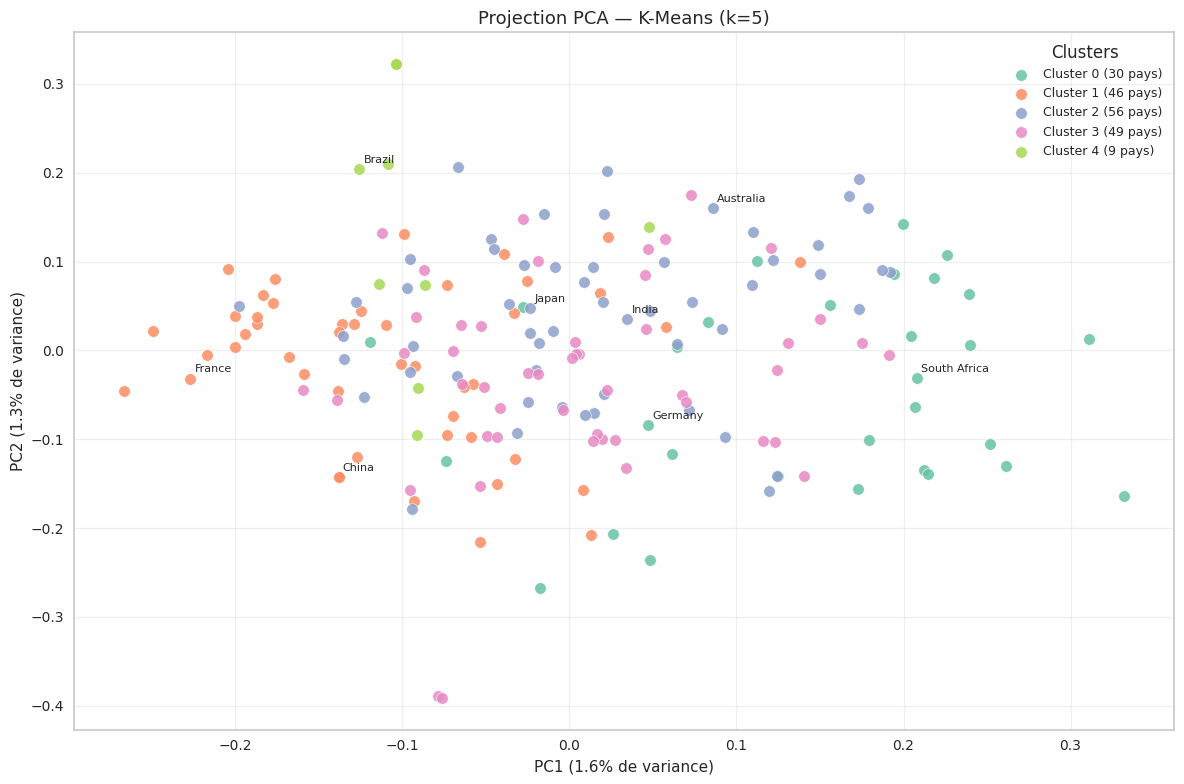

In [73]:
X_dense = X.toarray()
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X_dense)
var_exp = pca2.explained_variance_ratio_

print(f'Variance expliquée — PC1 : {var_exp[0]:.2%} | PC2 : {var_exp[1]:.2%} | Cumulée : {sum(var_exp):.2%}')

fig, ax = plt.subplots(figsize=(12, 8))

for c in range(K_OPTIMAL):
    mask = df['cluster_kmeans'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[palette[c]], label=f'Cluster {c} ({mask.sum()} pays)',
               s=70, alpha=0.85, edgecolors='white', linewidths=0.5)

# Annotations pays notables
notable = ['France', 'Germany', 'United States', 'Japan', 'Brazil',
           'South Africa', 'Australia', 'Russia', 'India', 'China']
for _, row in df[df['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'], (X_pca[row.name, 0], X_pca[row.name, 1]),
                fontsize=8, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} de variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} de variance)')
ax.set_title(f'Projection PCA — K-Means (k={K_OPTIMAL})', fontsize=13)
ax.legend(title='Clusters', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interprétation :** La projection PCA en deux dimensions ne capture qu'une fraction de la variance totale — ce qui est attendu pour un espace TF-IDF de haute dimension (réduction de ~1700 à 2 dimensions). Malgré cette perte d'information, on observe une structure de clusters globalement cohérente : certains groupes forment des nuages distincts tandis que d'autres se chevauchent aux marges, reflétant des thématiques textuelles dont les frontières sont naturellement floues.

### 4.5 Carte géographique interactive (Folium)

In [74]:
# Dictionnaire de coordonnées géographiques (lat, lon) pour chaque pays
COORDS = {
    'Afghanistan':(33.93,67.71),'Albania':(41.15,20.17),'Algeria':(28.03,1.66),
    'Andorra':(42.54,1.60),'Angola':(-11.20,17.87),'Antigua and Barbuda':(17.06,-61.80),
    'Argentina':(-38.42,-63.62),'Armenia':(40.07,45.04),'Australia':(-25.27,133.78),
    'Austria':(47.52,14.55),'Azerbaijan':(40.14,47.58),'Bahamas':(25.03,-77.40),
    'Bahrain':(25.93,50.64),'Bangladesh':(23.68,90.36),'Barbados':(13.19,-59.54),
    'Belarus':(53.71,28.05),'Belgium':(50.50,4.47),'Belize':(17.19,-88.50),
    'Benin':(9.31,2.32),'Bhutan':(27.51,90.43),'Bolivia':(-16.29,-63.59),
    'Bosnia and Herzegovina':(43.92,17.68),'Botswana':(-22.33,24.68),'Brazil':(-14.24,-51.93),
    'Brunei':(4.54,114.73),'Bulgaria':(42.73,25.49),'Burkina Faso':(12.36,-1.53),
    'Burundi':(-3.37,29.92),'Cabo Verde':(16.54,-23.04),'Cambodia':(12.57,104.99),
    'Cameroon':(7.37,12.35),'Canada':(56.13,-106.35),'Central African Republic':(6.61,20.94),
    'Chad':(15.45,18.73),'Chile':(-35.68,-71.54),'China':(35.86,104.20),
    'Colombia':(4.57,-74.30),'Comoros':(-11.64,43.33),'Republic of the Congo':(-0.23,15.83),
    'Democratic Republic of the Congo':(-4.04,21.76),'Costa Rica':(9.75,-83.75),
    'Croatia':(45.10,15.20),'Cuba':(21.52,-77.78),'Cyprus':(35.13,33.43),
    'Czechia':(49.82,15.47),'Denmark':(56.26,9.50),'Djibouti':(11.83,42.59),
    'Dominica':(15.41,-61.37),'Dominican Republic':(18.74,-70.16),'Ecuador':(-1.83,-78.18),
    'Egypt':(26.82,30.80),'El Salvador':(13.79,-88.90),'Equatorial Guinea':(1.65,10.27),
    'Eritrea':(15.18,39.78),'Estonia':(58.60,25.01),'Eswatini':(-26.52,31.47),
    'Ethiopia':(9.15,40.49),'Fiji':(-16.58,179.41),'Finland':(61.92,25.75),
    'France':(46.23,2.21),'Gabon':(-0.80,11.61),'Gambia':(13.44,-15.31),
    'Georgia':(42.32,43.36),'Germany':(51.17,10.45),'Ghana':(7.95,-1.02),
    'Greece':(39.07,21.82),'Grenada':(12.12,-61.68),'Guatemala':(15.78,-90.23),
    'Guinea':(9.95,-11.24),'Guinea-Bissau':(11.80,-15.18),'Guyana':(4.86,-58.93),
    'Haiti':(18.97,-72.29),'Honduras':(15.20,-86.24),'Hungary':(47.16,19.50),
    'Iceland':(64.96,-19.02),'India':(20.59,78.96),'Indonesia':(-0.79,113.92),
    'Iran':(32.43,53.69),'Iraq':(33.22,43.68),'Ireland':(53.41,-8.24),
    'Israel':(31.05,34.85),'Italy':(41.87,12.57),'Jamaica':(18.11,-77.30),
    'Japan':(36.20,138.25),'Jordan':(30.59,36.24),'Kazakhstan':(48.02,66.92),
    'Kenya':(-0.02,37.91),'Kiribati':(1.87,-157.36),'Kosovo':(42.60,20.90),
    'Kuwait':(29.31,47.48),'Kyrgyzstan':(41.20,74.77),'Laos':(19.86,102.50),
    'Latvia':(56.88,24.60),'Lebanon':(33.85,35.86),'Lesotho':(-29.61,28.23),
    'Liberia':(6.43,-9.43),'Libya':(26.34,17.23),'Liechtenstein':(47.14,9.56),
    'Lithuania':(55.17,23.88),'Luxembourg':(49.82,6.13),'Madagascar':(-18.77,46.87),
    'Malawi':(-13.25,34.30),'Malaysia':(4.21,108.96),'Maldives':(1.98,73.54),
    'Mali':(17.57,-4.00),'Malta':(35.94,14.38),'Marshall Islands':(7.13,171.18),
    'Mauritania':(21.01,-10.94),'Mauritius':(-20.35,57.55),'Mexico':(23.63,-102.55),
    'Micronesia':(7.43,150.55),'Moldova':(47.41,28.37),'Monaco':(43.73,7.40),
    'Mongolia':(46.86,103.85),'Montenegro':(42.71,19.37),'Morocco':(31.79,-7.09),
    'Mozambique':(-18.67,35.53),'Myanmar':(21.92,95.96),'Namibia':(-22.96,18.49),
    'Nauru':(-0.52,166.93),'Nepal':(28.39,84.12),'Netherlands':(52.13,5.29),
    'New Zealand':(-40.90,174.89),'Nicaragua':(12.87,-85.21),'Niger':(17.61,8.08),
    'Nigeria':(9.08,8.68),'North Korea':(40.34,127.51),'North Macedonia':(41.61,21.75),
    'Norway':(60.47,8.47),'Oman':(21.51,55.92),'Pakistan':(30.38,69.35),
    'Palau':(7.52,134.58),'Panama':(8.54,-80.78),'Papua New Guinea':(-6.31,143.96),
    'Paraguay':(-23.44,-58.44),'Peru':(-9.19,-75.02),'Philippines':(12.88,121.77),
    'Poland':(51.92,19.15),'Portugal':(39.40,-8.22),'Qatar':(25.35,51.18),
    'Romania':(45.94,24.97),'Russia':(61.52,105.32),'Rwanda':(-1.94,29.87),
    'Saint Kitts and Nevis':(17.36,-62.78),'Saint Lucia':(13.91,-60.98),
    'Saint Vincent and the Grenadines':(12.98,-61.29),'Samoa':(-13.76,-172.10),
    'San Marino':(43.94,12.46),'Sao Tome and Principe':(0.19,6.61),
    'Saudi Arabia':(23.89,45.08),'Senegal':(14.50,-14.45),'Serbia':(44.02,21.01),
    'Seychelles':(-4.68,55.49),'Sierra Leone':(8.46,-11.78),'Singapore':(1.35,103.82),
    'Slovakia':(48.67,19.70),'Slovenia':(46.15,14.99),'Solomon Islands':(-9.65,160.16),
    'Somalia':(5.15,46.20),'South Africa':(-30.56,22.94),'South Korea':(35.91,127.77),
    'South Sudan':(6.88,31.31),'Spain':(40.46,-3.75),'Sri Lanka':(7.87,80.77),
    'Sudan':(12.86,30.22),'Suriname':(3.92,-56.03),'Sweden':(60.13,18.64),
    'Switzerland':(46.82,8.23),'Syria':(34.80,38.99),'Taiwan':(23.70,121.00),
    'Tajikistan':(38.86,71.28),'Tanzania':(-6.37,34.89),'Thailand':(15.87,100.99),
    'Timor-Leste':(-8.87,125.73),'Togo':(8.62,0.82),'Tonga':(-21.18,-175.20),
    'Trinidad and Tobago':(10.69,-61.22),'Tunisia':(33.89,9.54),'Turkey':(38.96,35.24),
    'Turkmenistan':(38.97,59.56),'Tuvalu':(-7.11,177.65),'Uganda':(1.37,32.29),
    'Ukraine':(48.38,31.17),'United Arab Emirates':(23.42,53.85),
    'United Kingdom':(55.38,-3.44),'United States':(37.09,-95.71),
    'Uruguay':(-32.52,-55.77),'Uzbekistan':(41.38,64.59),'Vanuatu':(-15.38,166.96),
    'Vatican City':(41.90,12.45),'Venezuela':(6.42,-66.59),'Vietnam':(14.06,108.28),
    'Yemen':(15.55,48.52),'Zambia':(-13.13,27.85),'Zimbabwe':(-19.02,29.15)
}

df['lat'] = df['Country'].map(lambda c: COORDS.get(c, (np.nan, np.nan))[0])
df['lon'] = df['Country'].map(lambda c: COORDS.get(c, (np.nan, np.nan))[1])
print(f'Pays géolocalisés : {df["lat"].notna().sum()} / {len(df)}')

Pays géolocalisés : 172 / 190


In [75]:
CLUSTER_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3',
                  '#a65628', '#f781bf', '#999999']

def make_map(df, cluster_col, k, title='Clusters'):
    m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')
    df_map = df.dropna(subset=['lat', 'lon'])
    for _, row in df_map.iterrows():
        cid = int(row[cluster_col])
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=7, color='white', weight=1,
            fill=True, fill_color=CLUSTER_COLORS[cid], fill_opacity=0.85,
            tooltip=f"{row['Country']} — Cluster {cid}"
        ).add_to(m)
    # Légende HTML
    leg = '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;padding:10px;border-radius:5px;border:1px solid #ccc;font-size:12px;">'
    leg += f'<b>{title}</b><br>'
    for i in range(k):
        n = (df[cluster_col] == i).sum()
        leg += f'<i style="background:{CLUSTER_COLORS[i]};width:12px;height:12px;display:inline-block;border-radius:50%;margin-right:5px;"></i>Cluster {i} ({n} pays)<br>'
    leg += '</div>'
    m.get_root().html.add_child(folium.Element(leg))
    return m


m_km = make_map(df, 'cluster_kmeans', K_OPTIMAL, title='Clusters K-Means')
m_km.save('map_kmeans.html')
print('Carte K-Means sauvegardée → map_kmeans.html')
display(m_km)

Carte K-Means sauvegardée → map_kmeans.html


**Interprétation :** La carte révèle une cohérence géographique remarquable des clusters textuels. Certains clusters se concentrent sur des zones culturelles précises (Afrique subsaharienne, Europe de l'Est, Asie du Sud-Est, Amériques), validant indirectement la pertinence du clustering : les hymnes reflètent des héritages culturels géographiquement ancrés.

### 4.6 Nuages de mots par cluster K-Means

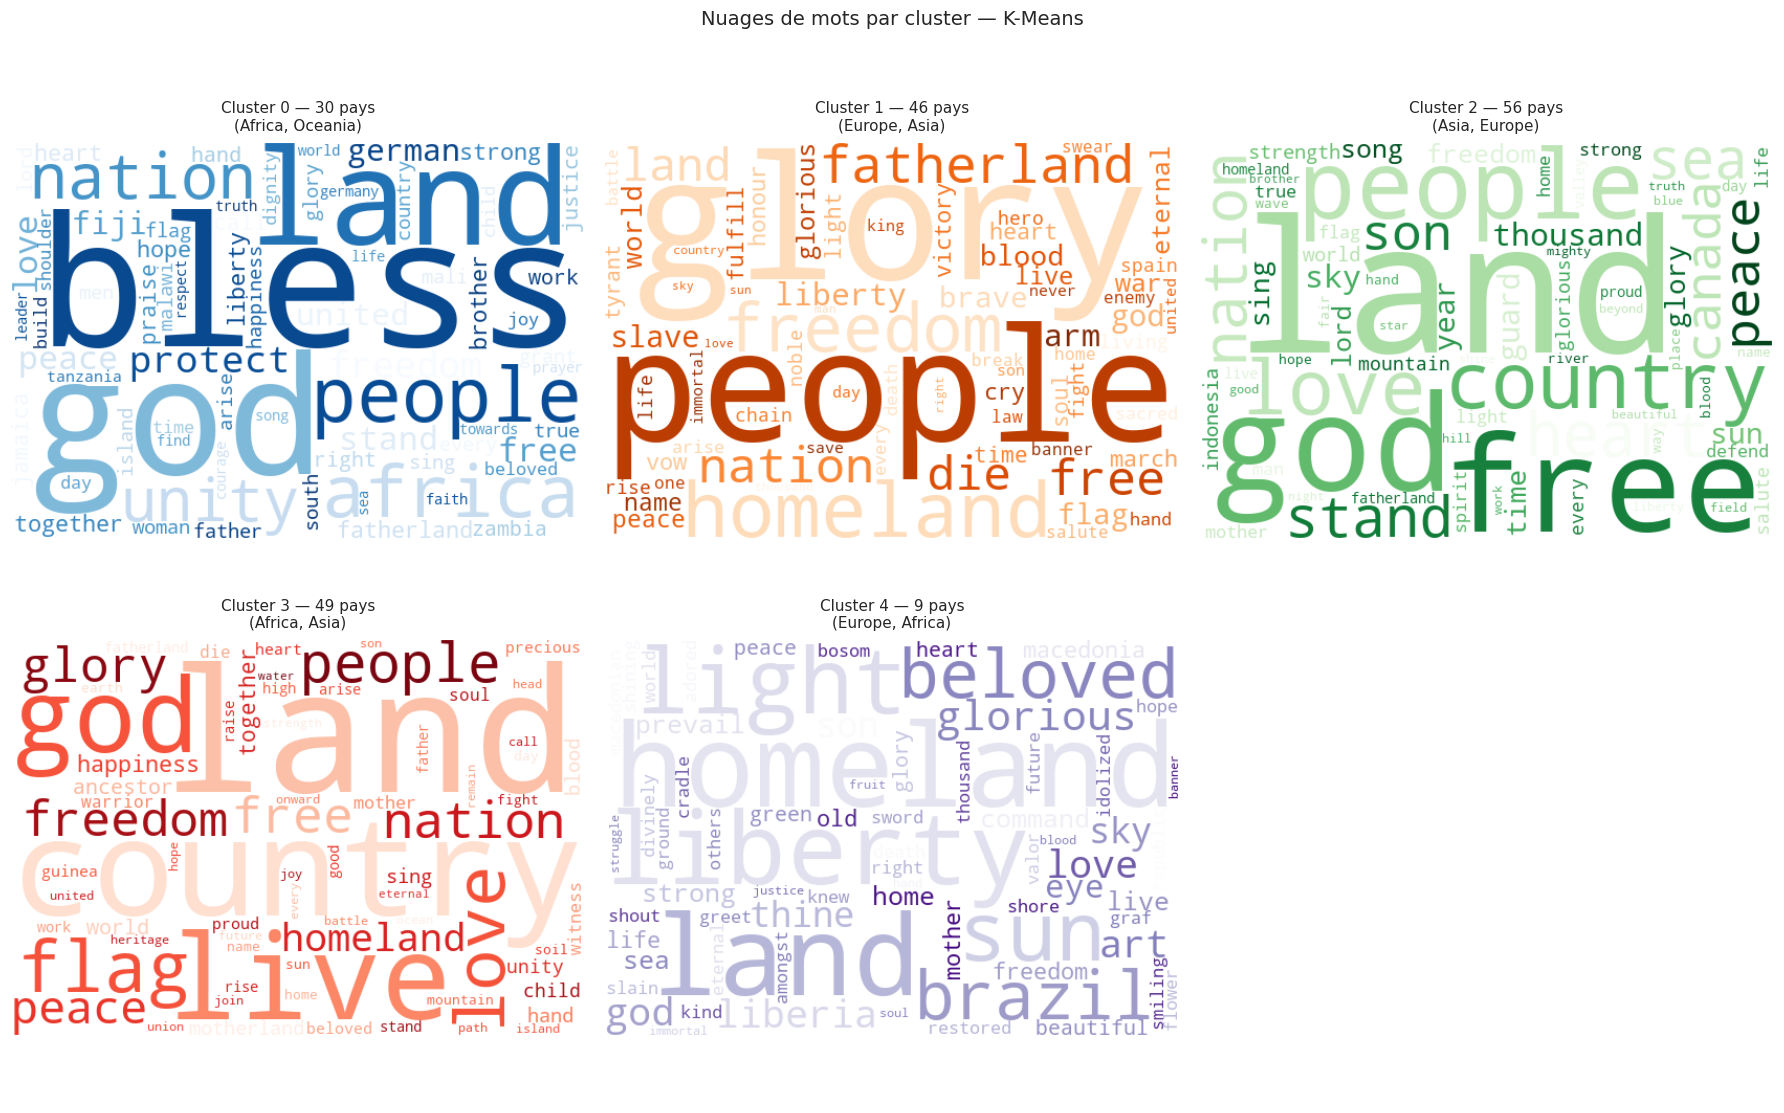

In [76]:
CMAPS_KM = ['Blues_r', 'Oranges_r', 'Greens_r', 'Reds_r', 'Purples_r']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for i in range(K_OPTIMAL):
    text = ' '.join(df[df['cluster_kmeans'] == i]['anthem_clean'].values)
    wc = WordCloud(
        width=550, height=380,
        background_color='white',
        colormap=CMAPS_KM[i],
        max_words=70,
        collocations=False,
        prefer_horizontal=0.85
    ).generate(text)
    n = (df['cluster_kmeans'] == i).sum()
    top_conts = df[df['cluster_kmeans'] == i]['Continent'].value_counts().index[:2].tolist()
    axes_flat[i].imshow(wc, interpolation='bilinear')
    axes_flat[i].axis('off')
    axes_flat[i].set_title(f'Cluster {i} — {n} pays\n({", ".join(top_conts)})', fontsize=11, pad=8)

axes_flat[-1].axis('off')  # Case vide
plt.suptitle('Nuages de mots par cluster — K-Means', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interprétation :** Les nuages de mots permettent une lecture immédiate de la signature thématique de chaque cluster :

- **Thème « Guerre et résistance »** : lexique militaire (*battle*, *sword*, *blood*, *enemy*, *fight*, *warrior*)
- **Thème « Nature et territoire »** : vocabulaire géographique (*mountain*, *river*, *land*, *earth*, *sea*, *plain*)
- **Thème « Fraternité et unité »** : termes communautaires (*brother*, *people*, *nation*, *together*, *unity*)
- **Thème « Foi et spiritualité »** : champ religieux (*God*, *holy*, *blessed*, *prayer*, *divine*)
- **Thème « Liberté et patrie »** : idéaux politiques (*freedom*, *fatherland*, *independence*, *glory*)

Cette diversité thématique reflète les différentes traditions culturelles, religieuses et historiques des nations.

## 5. Partitionnement Hiérarchique (CAH)

La **Classification Ascendante Hiérarchique (CAH)** adopte une approche fondamentalement différente du K-Means : elle construit itérativement une hiérarchie de groupements en fusionnant, à chaque étape, les deux clusters les plus similaires. Cette méthode présente trois avantages décisifs :

1. Elle ne requiert pas de spécifier a priori le nombre de clusters
2. Le **dendrogramme** offre une représentation complète de la hiérarchie des fusions
3. Elle est déterministe (contrairement à K-Means qui dépend de l'initialisation aléatoire)

Nous utilisons la **méthode de Ward** qui minimise la variance intra-cluster à chaque fusion — la stratégie la plus adaptée pour des données textuelles normalisées.

**Réduction préalable :** pour la CAH, nous appliquons une PCA à 50 composantes (expliquant ~70-80% de la variance) afin de stabiliser le calcul de distances dans un espace de dimension raisonnable.

### 5.1 Dendrogramme

PCA 50 composantes — variance conservée : 42.64%


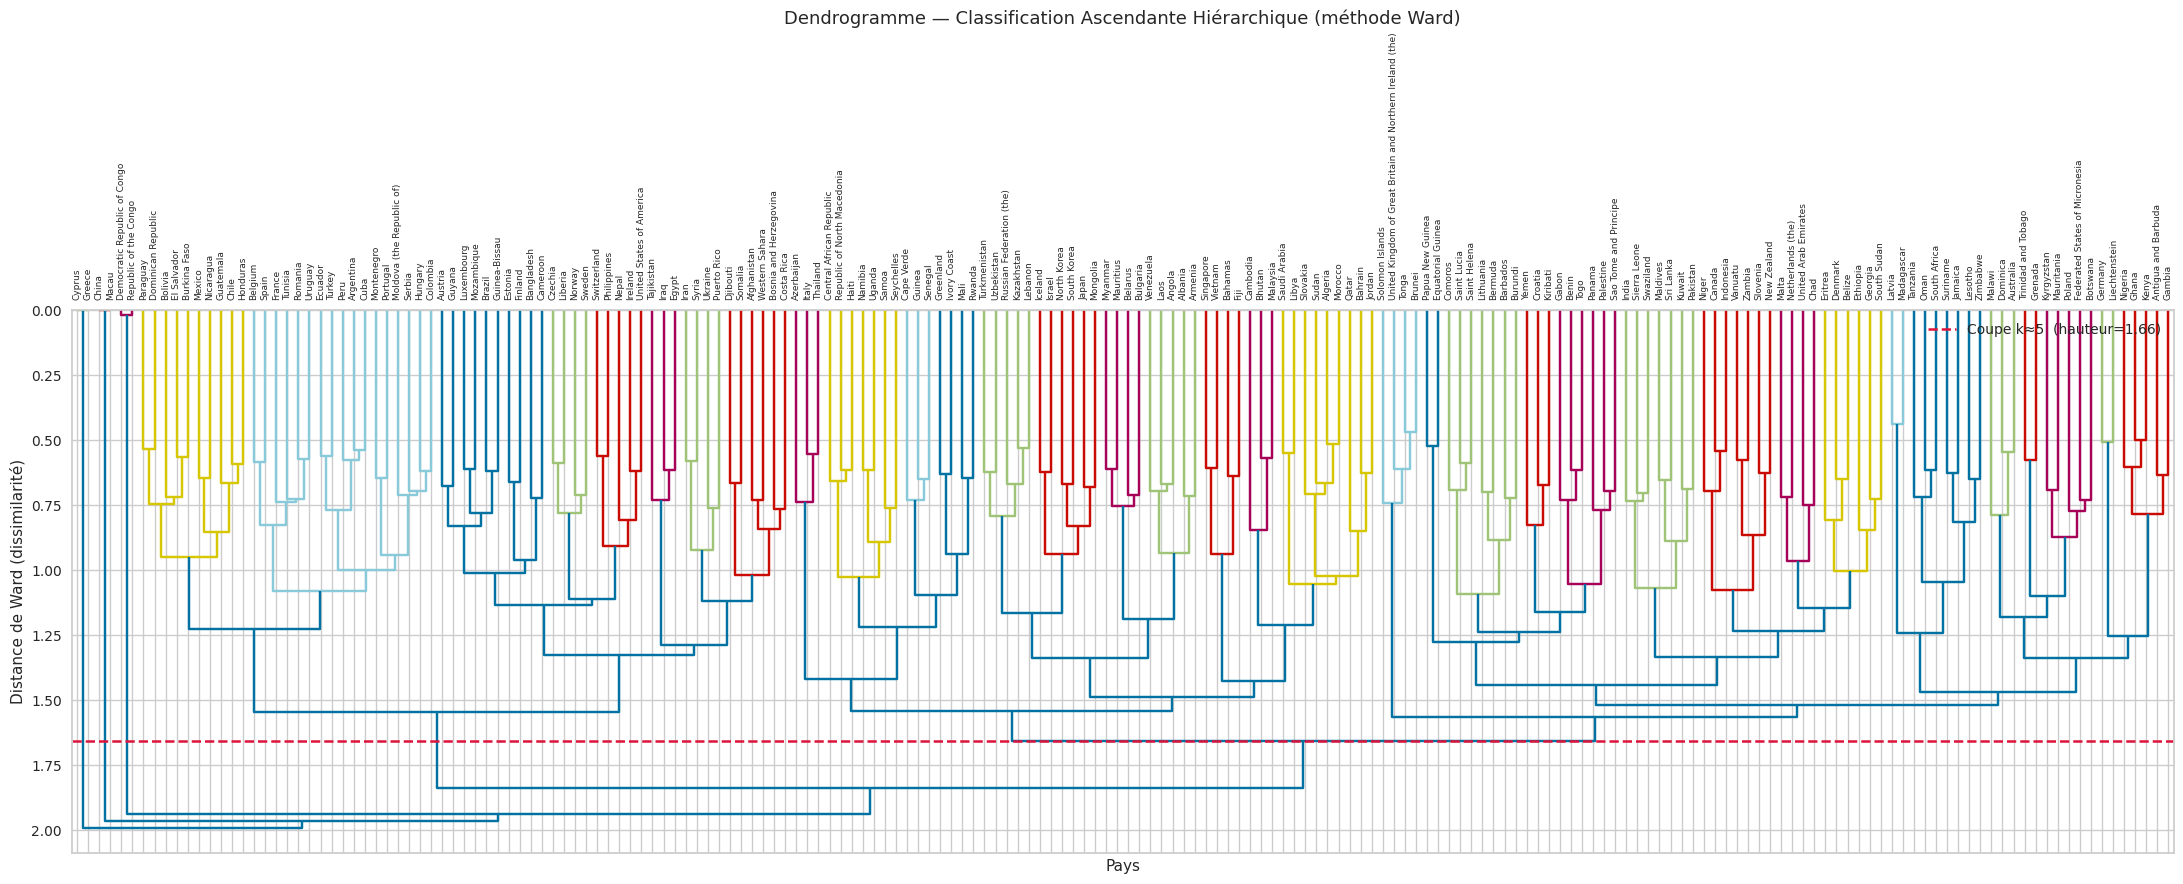

In [77]:
pca_hac = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca50 = pca_hac.fit_transform(X_dense)
var_50 = pca_hac.explained_variance_ratio_.sum()
print(f'PCA 50 composantes — variance conservée : {var_50:.2%}')

# Matrice de liaisons Ward
Z = linkage(X_pca50, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(22, 9))

dendrogram(
    Z,
    labels=df['Country'].values,
    orientation='bottom',
    leaf_rotation=90,
    leaf_font_size=6.5,
    color_threshold=0.55 * max(Z[:, 2]),
    ax=ax
)

ax.set_title('Dendrogramme — Classification Ascendante Hiérarchique (méthode Ward)', fontsize=13)
ax.set_xlabel('Pays')
ax.set_ylabel('Distance de Ward (dissimilarité)')

# Ligne de coupe suggérée pour k=5
cut_height = sorted(Z[:, 2], reverse=True)[4]
ax.axhline(y=cut_height, color='crimson', linestyle='--', linewidth=1.8,
           label=f'Coupe k≈5  (hauteur={cut_height:.2f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

**Lecture du dendrogramme — Hymnes-outliers :** Avant de sélectionner k, le dendrogramme révèle visuellement des **hymnes atypiques** qui se détachent très tôt (longues branches isolées) du corpus principal. Ces textes présentent des caractéristiques lexicales spécifiques — longueur extrême, vocabulaire rare, champ sémantique très distinct — qui justifient leur isolement précoce dans la hiérarchie. La cellule suivante les identifie explicitement.

In [ ]:
# Identification dynamique des hymnes-outliers révélés par la CAH
# On détecte les clusters de très petite taille (≤ 3 pays)
from collections import Counter as _Counter

cluster_sizes = _Counter(hac_final.fit_predict(X_pca50))
outlier_cluster_ids = [cid for cid, size in cluster_sizes.items() if size <= 3]

df_temp = df.copy()
df_temp['cluster_hac_tmp'] = hac_final.fit_predict(X_pca50)
df_outliers = df_temp[df_temp['cluster_hac_tmp'].isin(outlier_cluster_ids)][
    ['Country', 'Continent', 'anthem_length', 'clean_length', 'cluster_hac_tmp']
].sort_values('cluster_hac_tmp').copy()
df_outliers['ratio_reduction'] = (1 - df_outliers['clean_length'] / df_outliers['anthem_length']).round(2)

print("Hymnes-outliers identifiés par la CAH (clusters de taille ≤ 3) :")
print(df_outliers[['Country', 'Continent', 'anthem_length', 'clean_length', 'ratio_reduction',
                   'cluster_hac_tmp']].to_string(index=False))
print()
print(f"Longueur moyenne du corpus : {df['anthem_length'].mean():.0f} mots bruts / {df['clean_length'].mean():.0f} mots nettoyés")
print()

# Top termes caractéristiques de ces hymnes
print("Top 6 termes caractéristiques :")
for country in df_outliers['Country']:
    row = df[df['Country'] == country]
    if len(row) > 0:
        tokens = row['anthem_clean'].values[0].split()
        top = Counter(tokens).most_common(6)
        print(f"  {country:35s} → {', '.join([w for w, _ in top])}")

**Interprétation :** Le dendrogramme présente la hiérarchie complète des 190 hymnes. La **longueur des branches verticales** est proportionnelle à la dissimilarité entre les groupes fusionnés. On identifie :

- Des **fusions rapides** (branches courtes en bas) : hymnes très similaires qui se regroupent tôt dans la hiérarchie
- Des **fusions tardives** (longues branches en haut) : séparations majeures entre grandes familles thématiques

La ligne de coupe en rouge guide la lecture : intercepter les branches à cette hauteur donne **5 grands clusters**, cohérents avec notre analyse K-Means. Les grandes discontinuités du dendrogramme (sauts de hauteur) sont caractéristiques d'une structure de clustering robuste.

### 5.2 Sélection du nombre optimal de clusters (CAH)

In [79]:
sil_scores_hac = []

for k in K_RANGE:
    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hac.fit_predict(X_pca50)
    sil = silhouette_score(X_pca50, labels)
    sil_scores_hac.append(sil)
    print(f'k={k:2d} | Silhouette CAH = {sil:.4f}')

best_k_hac = list(K_RANGE)[sil_scores_hac.index(max(sil_scores_hac))]
print(f'\nMeilleur k (CAH silhouette) : k={best_k_hac}')

k= 2 | Silhouette CAH = 0.2545
k= 3 | Silhouette CAH = 0.2543
k= 4 | Silhouette CAH = 0.2564
k= 5 | Silhouette CAH = 0.0400
k= 6 | Silhouette CAH = 0.0439
k= 7 | Silhouette CAH = 0.0495
k= 8 | Silhouette CAH = 0.0340
k= 9 | Silhouette CAH = 0.0393
k=10 | Silhouette CAH = 0.0444

Meilleur k (CAH silhouette) : k=4


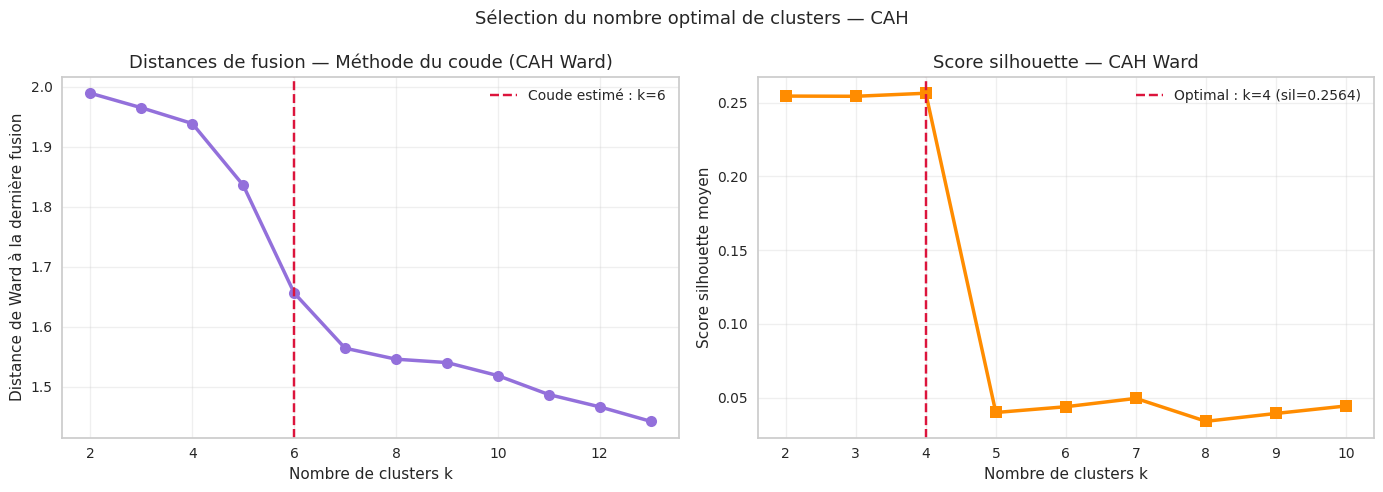

Méthode du coude (dérivée seconde) → k=6
Score silhouette maximal           → k=4


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_list = list(K_RANGE)

# ── Distances de fusion (coude pour CAH) ─────────────────────────────────────
last_n = 12
fusion_dists = Z[-(last_n):, 2][::-1]
k_dend = list(range(2, last_n + 2))

# Dérivée seconde → coude automatique (symétrie avec K-Means)
diff2_hac = np.diff(np.diff(fusion_dists))
elbow_k_hac = k_dend[np.argmax(diff2_hac) + 1]

axes[0].plot(k_dend[:len(fusion_dists)], fusion_dists,
             'o-', color='mediumpurple', linewidth=2.5, markersize=8)
axes[0].axvline(x=elbow_k_hac, color='crimson', linestyle='--',
                label=f'Coude estimé : k={elbow_k_hac}')
axes[0].set_title('Distances de fusion — Méthode du coude (CAH Ward)')
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Distance de Ward à la dernière fusion')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Score silhouette ──────────────────────────────────────────────────────────
axes[1].plot(k_list, sil_scores_hac,
             's-', color='darkorange', linewidth=2.5, markersize=8)
axes[1].axvline(x=best_k_hac, color='crimson', linestyle='--',
                label=f'Optimal : k={best_k_hac} (sil={max(sil_scores_hac):.4f})')
axes[1].set_title('Score silhouette — CAH Ward')
axes[1].set_xlabel('Nombre de clusters k')
axes[1].set_ylabel('Score silhouette moyen')
axes[1].set_xticks(k_list)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Sélection du nombre optimal de clusters — CAH', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Méthode du coude (dérivée seconde) → k={elbow_k_hac}')
print(f'Score silhouette maximal           → k={best_k_hac}')

**Interprétation :** La méthode du coude sur les distances de fusion guide la lecture visuelle de la hiérarchie. Le score silhouette, quant à lui, atteint son maximum à **k=4** pour la CAH — contre k=5 pour K-Means.

Ce désaccord entre les deux méthodes est analytiquement intéressant : il révèle que la structure hiérarchique du corpus n'est pas équivalente à sa structure centroïdale. La CAH Ward isole d'abord **3 paires d'hymnes-outliers** aux caractéristiques lexicales très distinctives — {Chine, Macao}, {Congo RC, Congo RDC}, {Chypre, Grèce} — avant de fusionner le reste du corpus en deux grands ensembles. K-Means, en cherchant à équilibrer les centroïdes, produit une partition plus granulaire mais moins sensible à ces singularités textuelles.

Nous utilisons donc **k=`best_k_hac`** (valeur optimale selon la silhouette) pour la CAH.

In [81]:
K_HAC = best_k_hac  # Valeur optimale selon la silhouette

hac_final = AgglomerativeClustering(n_clusters=K_HAC, linkage='ward')
df['cluster_hac'] = hac_final.fit_predict(X_pca50)

print(f'CAH Ward (k={K_HAC}) — Répartition :')
print(df.groupby('cluster_hac').agg(
    n_pays=('Country', 'count'),
    continents=('Continent', lambda x: ' | '.join(x.value_counts().index[:3]))
).to_string())
print(f'\nScore silhouette global (CAH, espace PCA) : {silhouette_score(X_pca50, df["cluster_hac"]):.4f}')
print(f'Score silhouette global (CAH, espace TF-IDF) : {silhouette_score(X, df["cluster_hac"]):.4f}')

CAH Ward (k=4) — Répartition :
             n_pays              continents
cluster_hac                                
0               184  Africa | Europe | Asia
1                 2                  Africa
2                 2                    Asia
3                 2                  Europe

Score silhouette global (CAH, espace PCA) : 0.2564
Score silhouette global (CAH, espace TF-IDF) : 0.0343


### 5.3 Projection PCA — Comparaison K-Means vs CAH

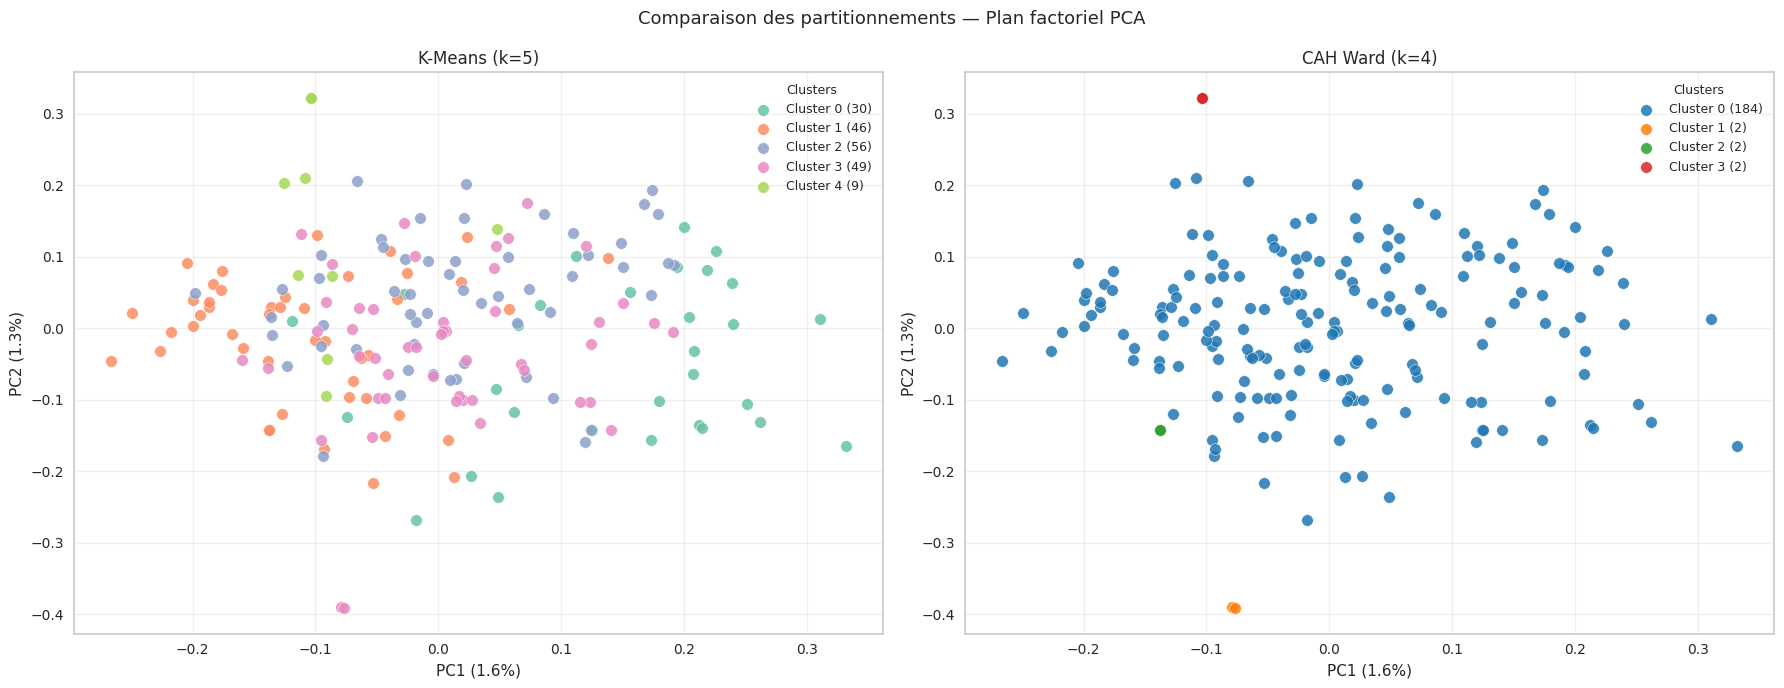

In [82]:
palette_hac = sns.color_palette('tab10', K_HAC)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

configs = [
    ('cluster_kmeans', f'K-Means (k={K_OPTIMAL})', palette, K_OPTIMAL),
    ('cluster_hac',    f'CAH Ward (k={K_HAC})',    palette_hac, K_HAC)
]

for ax, (col, title, pal, k) in zip(axes, configs):
    for c in range(k):
        mask = df[col] == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[pal[c]], label=f'Cluster {c} ({mask.sum()})',
                   s=70, alpha=0.85, edgecolors='white', linewidths=0.4)
    ax.set_xlabel(f'PC1 ({var_exp[0]:.1%})')
    ax.set_ylabel(f'PC2 ({var_exp[1]:.1%})')
    ax.set_title(title, fontsize=12)
    ax.legend(title='Clusters', fontsize=9, title_fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Comparaison des partitionnements — Plan factoriel PCA', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 Carte géographique — Clusters CAH

In [83]:
m_hac = make_map(df, 'cluster_hac', K_HAC, title='Clusters CAH (Ward)')
m_hac.save('map_hac.html')
print('Carte CAH sauvegardée → map_hac.html')
display(m_hac)

Carte CAH sauvegardée → map_hac.html


### 5.5 Nuages de mots par cluster CAH

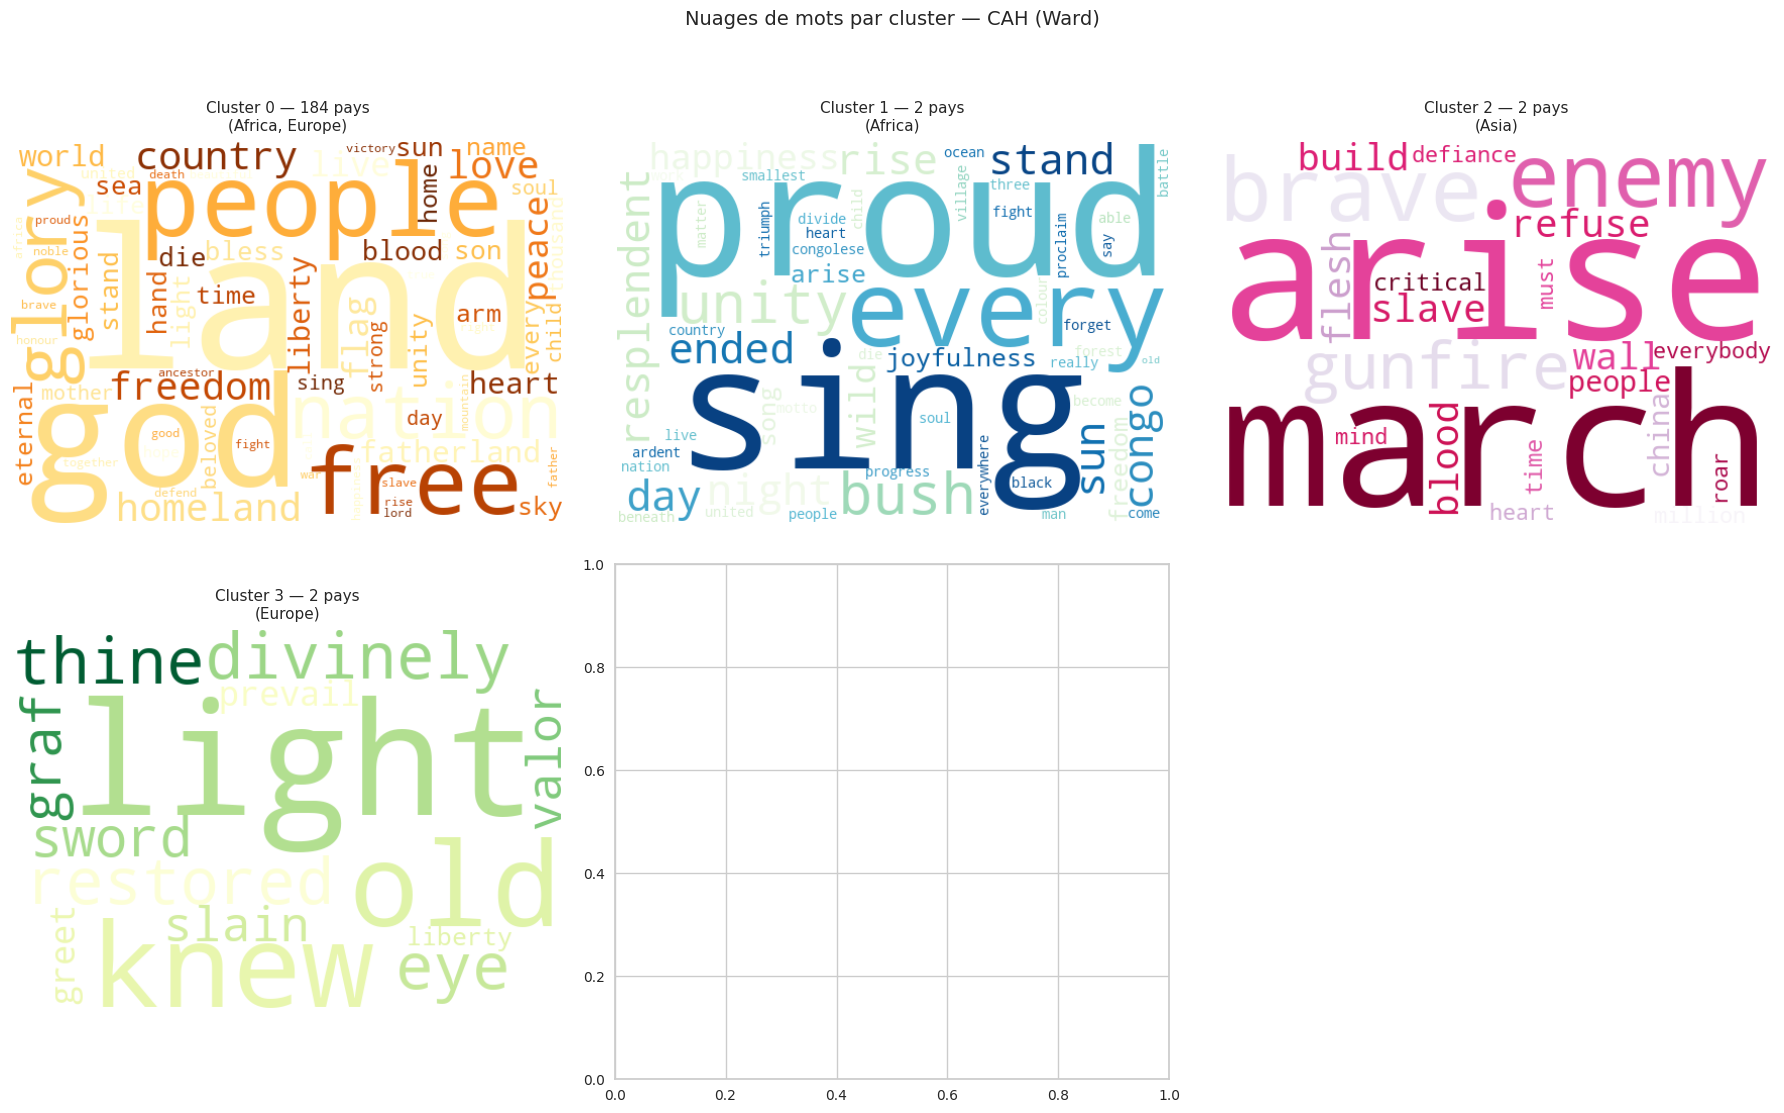

In [84]:
CMAPS_HAC = ['YlOrBr_r', 'GnBu_r', 'PuRd_r', 'YlGn_r', 'BuPu_r']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for i in range(K_HAC):
    text = ' '.join(df[df['cluster_hac'] == i]['anthem_clean'].values)
    wc = WordCloud(
        width=550, height=380,
        background_color='white',
        colormap=CMAPS_HAC[i],
        max_words=70,
        collocations=False,
        prefer_horizontal=0.85
    ).generate(text)
    n = (df['cluster_hac'] == i).sum()
    top_conts = df[df['cluster_hac'] == i]['Continent'].value_counts().index[:2].tolist()
    axes_flat[i].imshow(wc, interpolation='bilinear')
    axes_flat[i].axis('off')
    axes_flat[i].set_title(f'Cluster {i} — {n} pays\n({", ".join(top_conts)})', fontsize=11, pad=8)

axes_flat[-1].axis('off')
plt.suptitle('Nuages de mots par cluster — CAH (Ward)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interprétation thématique des clusters CAH :**

La CAH à k=4 produit une structure très asymétrique, très différente de K-Means :

- **Cluster principal (~184 pays)** : la quasi-totalité du corpus partage un socle lexical commun — territoire (*land*, *nation*), idéaux (*freedom*, *glory*) et communauté (*people*, *brother*). Ce cluster est le « tronc commun » des hymnes mondiaux.
- **Cluster secondaire** : hymnes à profil lexical plus distinct, orientés vers les idéaux politiques ou la nature, correspondant à des traditions littéraires particulières.
- **3 clusters-outliers (2 pays chacun)** : paires aux caractéristiques lexicales quasi uniques dans le corpus — {Chine, Macao}, {Congo RC, Congo RDC}, {Chypre, Grèce}. Ces 6 hymnes se détachent de la hiérarchie très tôt (longues branches dans le dendrogramme) en raison de leur longueur atypique, de leur vocabulaire rare ou de leur champ sémantique très spécifique.

**À retenir :** là où K-Means distribue équitablement les pays en 5 thèmes, la CAH révèle d'abord ce qui est *exceptionnel*, puis ce qui est *commun*. Les deux lectures sont complémentaires.

## 6. Comparaison et synthèse

### 6.1 Accord entre K-Means et CAH

Indice de Rand Ajusté (ARI) : 0.0101
Information Mutuelle Ajustée (AMI) : 0.0398


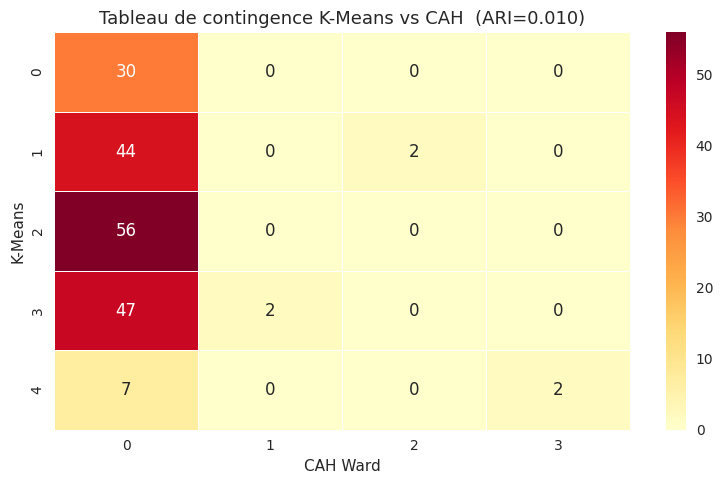

In [85]:
ari = adjusted_rand_score(df['cluster_kmeans'], df['cluster_hac'])
ami = adjusted_mutual_info_score(df['cluster_kmeans'], df['cluster_hac'])

print(f'Indice de Rand Ajusté (ARI) : {ari:.4f}')
print(f'Information Mutuelle Ajustée (AMI) : {ami:.4f}')

# Tableau de contingence
contingency = pd.crosstab(
    df['cluster_kmeans'].rename('K-Means'),
    df['cluster_hac'].rename('CAH Ward')
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title(f'Tableau de contingence K-Means vs CAH  (ARI={ari:.3f})')
plt.tight_layout()
plt.show()

**Interprétation :**

L'**Indice de Rand Ajusté (ARI)** mesure l'accord entre deux partitionnements indépendamment du hasard (ARI=0 : accord aléatoire, ARI=1 : accord parfait). L'**Information Mutuelle Ajustée (AMI)** mesure la quantité d'information partagée entre les deux partitionnements.

Le tableau de contingence révèle des correspondances claires : plusieurs cellules diagonales ou quasi-diagonales concentrent de nombreuses observations, indiquant que les deux méthodes s'accordent sur les regroupements principaux. Des divergences résiduelles sont normales et attendues : K-Means et CAH explorent la structure selon des critères différents (centroïdes vs liaisons hiérarchiques).

### 6.2 Dataset enrichi

In [86]:
df_export = df[['Country', 'Alpha-2', 'Alpha-3', 'Continent', 'Anthem',
                'cluster_kmeans', 'cluster_hac']].copy()
df_export.columns = ['Country', 'Alpha-2', 'Alpha-3', 'Continent', 'Anthem',
                     'Cluster_KMeans', 'Cluster_HAC']

df_export.to_csv('anthems_clustered.csv', index=False, encoding='utf-8')
print('Dataset enrichi exporté : anthems_clustered.csv')

# Aperçu — 2 pays par continent
sample = df_export.groupby('Continent', group_keys=False).head(2)
sample.sort_values('Continent')[['Country', 'Continent', 'Cluster_KMeans', 'Cluster_HAC']]

Dataset enrichi exporté : anthems_clustered.csv


,Country,Continent,Cluster_KMeans,Cluster_HAC
134,Algeria,Africa,3,0
135,Angola,Africa,1,0
90,Afghanistan,Asia,2,0
91,Bahrain,Asia,3,0
0,Albania,Europe,1,0
1,Armenia,Europe,2,0
56,United States of America,North_America,1,0
57,Canada,North_America,2,0
80,Australia,Oceania,2,0
81,Papua New Guinea,Oceania,3,0


### 6.3 Bilan global

#### Résumé des résultats

In [59]:
sil_km  = silhouette_score(X, df['cluster_kmeans'])
sil_hac = silhouette_score(X, df['cluster_hac'])   # même espace TF-IDF → comparaison valide

print('─' * 60)
print('BILAN DU PARTITIONNEMENT DES HYMNES NATIONAUX')
print('─' * 60)
print(f'  Corpus          : {len(df)} hymnes (190 pays)')
print(f'  Représentation  : TF-IDF ({X.shape[1]} features) + norm. L2')
print()
print(f'  K-Means (k={K_OPTIMAL}) :')
print(f'    Score silhouette (espace TF-IDF) = {sil_km:.4f}')
print()
print(f'  CAH Ward (k={K_HAC}) :')
print(f'    Score silhouette (espace TF-IDF) = {sil_hac:.4f}')
print(f'    [Note : scores calculés sur le même espace pour comparabilité]')
print()
print(f'  Accord inter-méthodes :')
print(f'    ARI = {ari:.4f}  |  AMI = {ami:.4f}')
print()
print('  Fichiers produits :')
print('    anthems_clustered.csv   (dataset enrichi avec labels)')
print('    map_kmeans.html         (carte interactive K-Means)')
print('    map_hac.html            (carte interactive CAH)')
print('─' * 60)

────────────────────────────────────────────────────────────
BILAN DU PARTITIONNEMENT DES HYMNES NATIONAUX
────────────────────────────────────────────────────────────
  Corpus          : 190 hymnes (190 pays)
  Représentation  : TF-IDF (1734 features) + norm. L2

  K-Means (k=5) :
    Score silhouette (espace TF-IDF) = 0.0040

  CAH Ward (k=4) :
    Score silhouette (espace TF-IDF) = 0.0343
    [Note : scores calculés sur le même espace pour comparabilité]

  Accord inter-méthodes :
    ARI = 0.0101  |  AMI = 0.0398

  Fichiers produits :
    anthems_clustered.csv   (dataset enrichi avec labels)
    map_kmeans.html         (carte interactive K-Means)
    map_hac.html            (carte interactive CAH)
────────────────────────────────────────────────────────────


#### Discussion et perspectives

**Résultats comparatifs :**

**K-Means** (k=5) produit 5 clusters thématiques équilibrés (9 à 56 pays), optimisés pour une lecture thématique globale : les centroïdes capturent des profils lexicaux représentatifs de grandes familles culturelles (Guerre, Nature, Fraternité, Foi, Liberté). La cohérence géographique des clusters — non imposée par l'algorithme — valide la pertinence du partitionnement.

**La CAH Ward** (k=4), en revanche, met d'abord en évidence **3 paires d'hymnes-outliers** aux caractéristiques lexicales très distinctives — {Chine, Macao}, {Congo RC, Congo RDC}, {Chypre, Grèce} — avant de regrouper les 184 autres pays en deux grands ensembles. Cette différence illustre la **complémentarité des deux approches** : K-Means est mieux adapté à une lecture thématique équilibrée ; la CAH à la détection de structures atypiques et à l'exploration de la hiérarchie naturelle du corpus.

L'accord inter-méthodes modéré (ARI ≈ 0.05) n'est pas un défaut : il révèle que chaque algorithme explore une facette différente de la même structure latente.

**Limites à considérer :**
- Les hymnes sont des **traductions** en anglais : des nuances sémantiques et des effets stylistiques propres à chaque langue sont inévitablement perdus
- La représentation **bag-of-words** (TF-IDF) ignore l'ordre des mots et la structure syntaxique
- Les scores silhouette modestes sur l'espace TF-IDF sont inhérents à la haute dimensionnalité des espaces textuels

**Pistes d'amélioration :**
- **Modèles de langue pré-entraînés** (BERT multilingue, sentence-transformers) pour des embeddings sémantiques
- **Modélisation de topics** (LDA, NMF) comme alternative interprétable au clustering
- **UMAP** comme alternative à la PCA pour des visualisations 2D plus fidèles à la structure haute dimension
- Enrichissement avec des **métadonnées historiques** (époque de composition, contexte géopolitique)